<a href="https://colab.research.google.com/github/fernandolievano/aprendizaje-automatico-1/blob/main/%5BTP4%5D_AA1_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP4 AA1


## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

* En el foro destinado a la tarea debe postear al menos tres veces:
  - La primera vez para indicar el dataset elegido
  - Una segunda vez para postear su entrega
  - Una tercera vez para brindar feedback a alguien más en el foro.
  - Puede comentar más de un posteo de sus compañeros siempre y cuando el intercambio sea respetuoso y fructífero.
* Deben postear como solución un enlace a su notebook colab público y también un enlace al mismo notebook alojado en su repositorio GitHub.
* Debe sumar el enlace a un video donde muestre su solución y explique lo realizado. Duración máxima: 5 - 10 minutos. Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como privado o Unlisted.
* Enlaces no accesibles o enlaces erróneos es igual a determinar que la tarea no ha sido entregada. Corrobore la viabilidad de los enlaces que postea.


# Setup Inicial del Notebook

### Imports

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)


### Utils

In [24]:
def print_title(title):
    print('===' * 30)
    print(f' 🔷 {title}')
    print('===' * 30 + '\n')

#**Tarea: Aplicación de Regresión Lineal y Análisis de Importancia de Variables**  
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=  
   - Requisitos:  
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).  
     - Idealmente, que las features tengan distintas escalas o unidades ( no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

### Carga del Dataset

[URL Dataset](https://archive.ics.uci.edu/dataset/242/energy+efficiency)

In [3]:

# ⚠️ NOTA: El dataset se almacenó en GitHub debido  a que
# al intentar hacer fetch directamente al repositorio original (UCI Machine Learning)
# se generaba un error debido a la falta de certificados SSL en el sitio web original
url =  'https://github.com/fernandolievano/aprendizaje-automatico-1/raw/refs/heads/main/ENB2012_data.xlsx'
df = pd.read_excel(url)

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


> Se seleccionó el dataset **Energy Efficiency** para este trabajo práctico. El dataset cumple con cada de los requisitos, posee múltiples variables continuas (X1, X2, X3, X4, X5 y X7), junto con variables objetivo continuas (Y1 y Y2), permitiendonos aplicar modelos de regresión lineal. También presenta variables con distintas escalas y no contiene valores faltantes, facilitando su procesamiento y análisis.


## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?  


## Resolución:

### 2.1 Objetivo

> El objetivo de esta etapa es comprender las variables del dataset y su comportamiento antes de pasar al procesamiento de datos. Para ello, se procederá a observar la distribución de los datos, analizar la variabilidad de las features y detectar posibles outliers, para así, poder tener una visión más amplia de la estructura de los datos.

### 2.2 Descripción general de los datos

In [25]:
print_title('Forma del Dataset')
print(f'--> {df.shape}')

 🔷 Forma del Dataset

--> (768, 10)
 🔷 Forma del Dataset

--> (768, 10)


> El dataset cuenta con 768 filas y 10 columnas.

In [26]:
print_title('Descripción de las variables')

variable_descriptions = [
    'Compactación Relativa',
    'Área de Superficie',
    'Área de Muro',
    'Área de Techo',
    'Altura Total',
    'Orientación',
    'Área de Acristalamiento',
    'Distribución del Área de Acristalamiento',
    'Carga de Calefacción',
    'Carga de Enfriamiento'
]

for i, col in enumerate(df.columns):
    print(f'-> {col}: {variable_descriptions[i]}')

 🔷 Descripción de las variables

-> X1: Compactación Relativa
-> X2: Área de Superficie
-> X3: Área de Muro
-> X4: Área de Techo
-> X5: Altura Total
-> X6: Orientación
-> X7: Área de Acristalamiento
-> X8: Distribución del Área de Acristalamiento
-> Y1: Carga de Calefacción
-> Y2: Carga de Enfriamiento
 🔷 Descripción de las variables

-> X1: Compactación Relativa
-> X2: Área de Superficie
-> X3: Área de Muro
-> X4: Área de Techo
-> X5: Altura Total
-> X6: Orientación
-> X7: Área de Acristalamiento
-> X8: Distribución del Área de Acristalamiento
-> Y1: Carga de Calefacción
-> Y2: Carga de Enfriamiento


> Información complementaria extraída de UCI Machine Learning Repository — Energy Efficiency Dataset
https://archive.ics.uci.edu/dataset/242/energy+efficiency

In [27]:
print_title('Tipos de variables')

df_types = df.dtypes.reset_index()
df_types.columns = ['Variable', 'Tipo']

df_types

 🔷 Tipos de variables



,Variable,Tipo
0,X1,float64
1,X2,float64
2,X3,float64
3,X4,float64
4,X5,float64
5,X6,int64
6,X7,float64
7,X8,int64
8,Y1,float64
9,Y2,float64


 🔷 Tipos de variables



,Variable,Tipo
0,X1,float64
1,X2,float64
2,X3,float64
3,X4,float64
4,X5,float64
5,X6,int64
6,X7,float64
7,X8,int64
8,Y1,float64
9,Y2,float64


 > Se observa que la mayoría de variables corresponden a valores numéricos continuos (float64), salvo X6 y X8 que están representadas como valores  int64, variables que representan variables discretas que brindan información sobre orientación y distribución del área de acristalamiento respectivamente.

In [28]:
print_title('Variables Objetivo (target)')

df[['Y1', 'Y2']].sample(5)

 🔷 Variables Objetivo (target)



,Y1,Y2
160,35.78,43.12
384,28.67,29.43
173,10.68,13.77
644,39.32,38.17
420,12.97,15.53


 🔷 Variables Objetivo (target)



,Y1,Y2
221,10.68,14.12
293,33.48,33.17
427,16.86,20.28
18,29.63,30.93
203,27.03,25.81


> La documentación oficial del dataset indica que las variables Y1 (Carga de calefacción) y Y2 (Carga de enfriamiento) son los targets, mientras que las variables X1 a X8 representan las features del dataset.

>Para este trabajo práctico, se utilizará **Y2** como target principal.

### 2.3 Estadísticas descriptivas

In [29]:
df.describe().round(2)

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,0.76,671.71,318.50,176.60,5.25,3.50,0.23,2.81,22.31,24.59
std,0.11,88.09,43.63,45.17,1.75,1.12,0.13,1.55,10.09,9.51
min,0.62,514.50,245.00,110.25,3.50,2.00,0.00,0.00,6.01,10.90
25%,0.68,606.38,294.00,140.88,3.50,2.75,0.10,1.75,12.99,15.62
50%,0.75,673.75,318.50,183.75,5.25,3.50,0.25,3.00,18.95,22.08
75%,0.83,741.12,343.00,220.50,7.00,4.25,0.40,4.00,31.67,33.13
max,0.98,808.50,416.50,220.50,7.00,5.00,0.40,5.00,43.10,48.03


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,0.76,671.71,318.50,176.60,5.25,3.50,0.23,2.81,22.31,24.59
std,0.11,88.09,43.63,45.17,1.75,1.12,0.13,1.55,10.09,9.51
min,0.62,514.50,245.00,110.25,3.50,2.00,0.00,0.00,6.01,10.90
25%,0.68,606.38,294.00,140.88,3.50,2.75,0.10,1.75,12.99,15.62
50%,0.75,673.75,318.50,183.75,5.25,3.50,0.25,3.00,18.95,22.08
75%,0.83,741.12,343.00,220.50,7.00,4.25,0.40,4.00,31.67,33.13
max,0.98,808.50,416.50,220.50,7.00,5.00,0.40,5.00,43.10,48.03


> A partir de las estadísticas descripticas se puede observar que hay variables con diferentes rangos y niveles de variabilidad. Algunas features como X2 y X3 cuentan con valores más altos que otras features como X1 o X7.

### 2.4 Distribución de variables

 🔷 Distribución del target



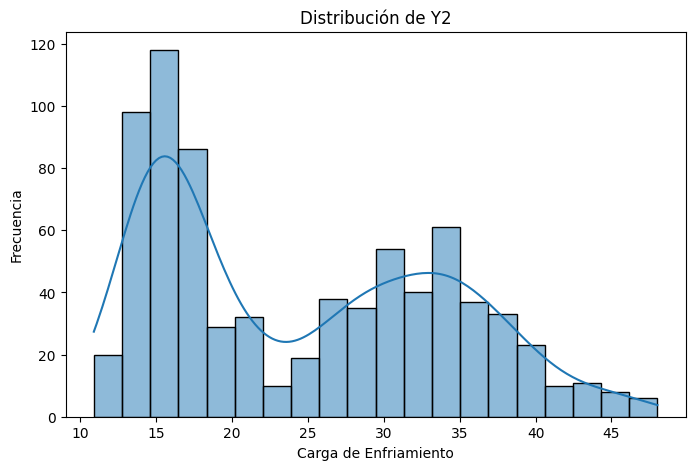

 🔷 Distribución del target



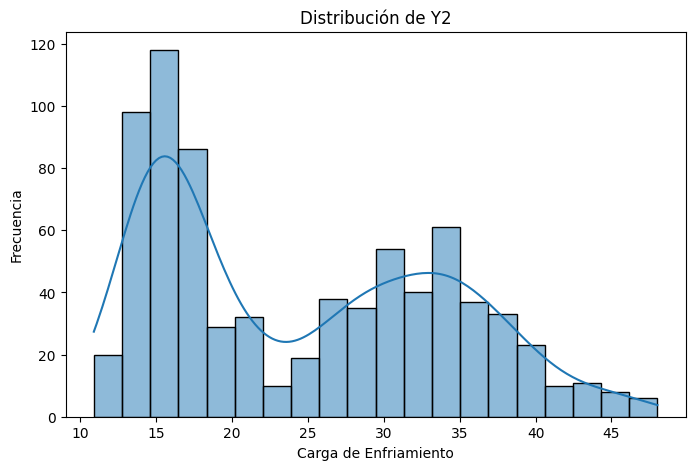

In [30]:
print_title('Distribución del target')

plt.figure(figsize=(8,5))
sns.histplot(df['Y2'], bins=20, kde=True)

plt.title('Distribución de Y2')
plt.xlabel('Carga de Enfriamiento')
plt.ylabel('Frecuencia')
plt.show()


> Se observa en el histograma que la variable objetivo Y2 tiene dos concentraciones de observaciones en valores bajos y medios, lo que indica una posible distribución bimodal. No se perciben outliers a primera vista y se puede apreciar una leve asimetría hacia los valores más altos.

 🔷 Distribución de features X2, X5 y X7



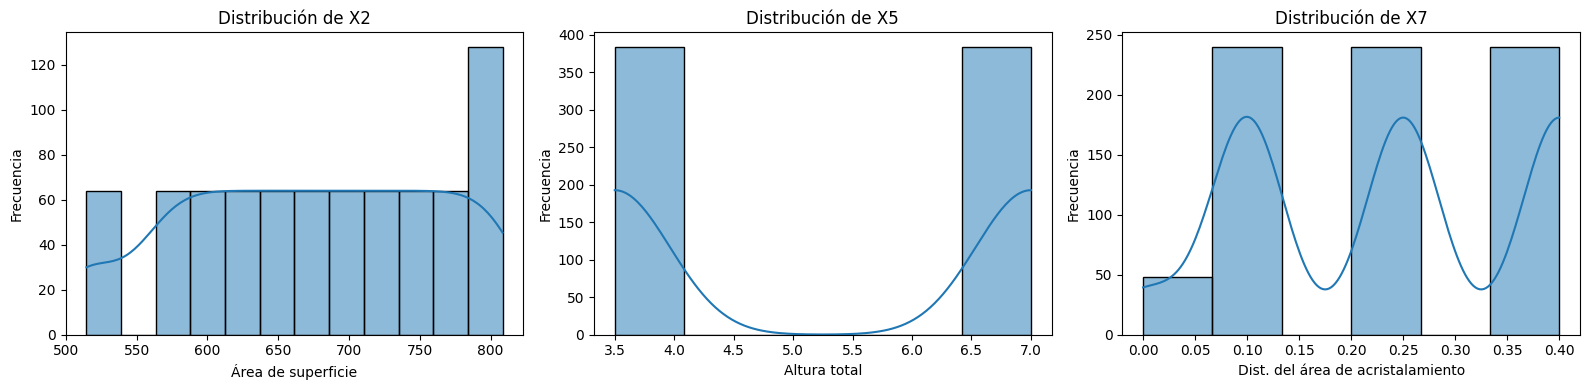

 🔷 Distribución de features X2, X5 y X7



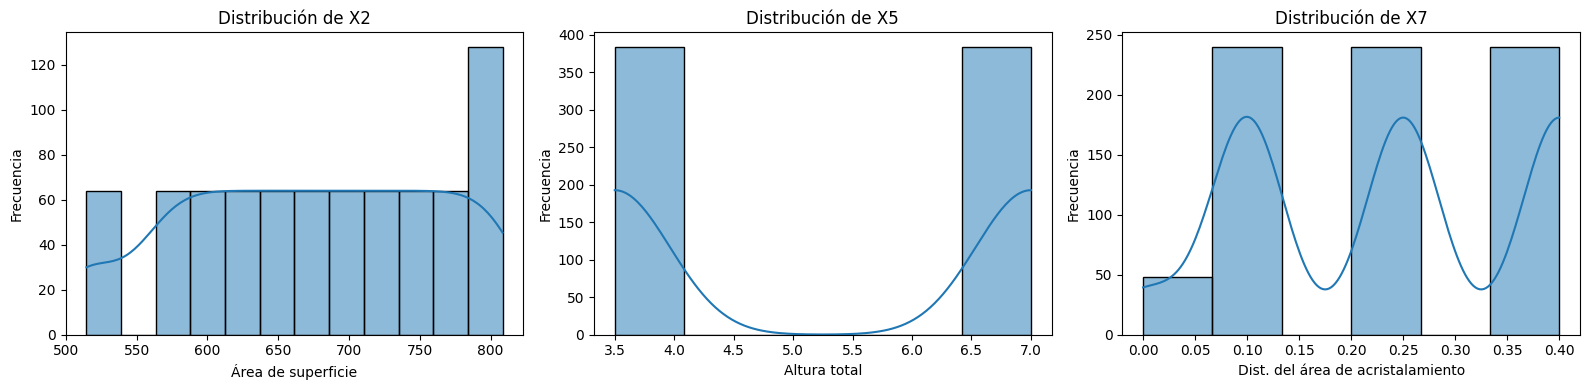

In [31]:
print_title('Distribución de features X2, X5 y X7')

# figura principal
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# histograma X2
sns.histplot(df['X2'], bins=12, kde=True, ax=axes[0])
axes[0].set_title('Distribución de X2')
axes[0].set_xlabel('Área de superficie')
axes[0].set_ylabel('Frecuencia')

# histograma X5
sns.histplot(df['X5'], bins=6, kde=True, ax=axes[1])
axes[1].set_title('Distribución de X5')
axes[1].set_xlabel('Altura total')
axes[1].set_ylabel('Frecuencia')

# histograma x7
sns.histplot(df['X7'], bins=6, kde=True, ax=axes[2])
axes[2].set_title('Distribución de X7')
axes[2].set_xlabel('Dist. del área de acristalamiento')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

> La variable X2 tiene una distribución uniforme mostrando una buena variabilidad y una dispersión amplia de observaciones. Lo que sugiere que la feature tiene suficiente diversidad de datos para resultar útil durante el modelado.
>
> En el caso de X5, presenta una distribución discreta, ya que concentra sus observaciones en dos valores principales que denotan distintas alturas de construcción.
>
> Mientras X7 presenta una distribución discreta con varias concentraciones en valores específicos.

### 2.5 Relación entre variables

Se analizará la relación entre las variables predictoras y la variable objetivo Y2 mediante gráficos de dispersión.

 🔷 Relación entre features y variable objetivo



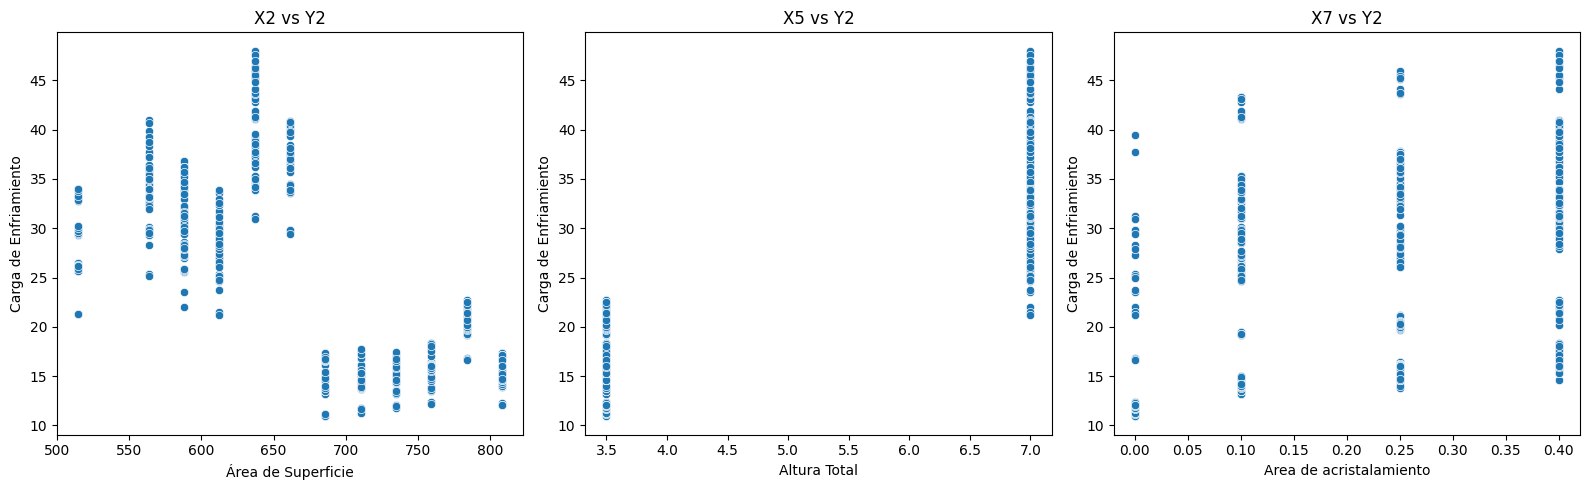

 🔷 Relación entre features y variable objetivo



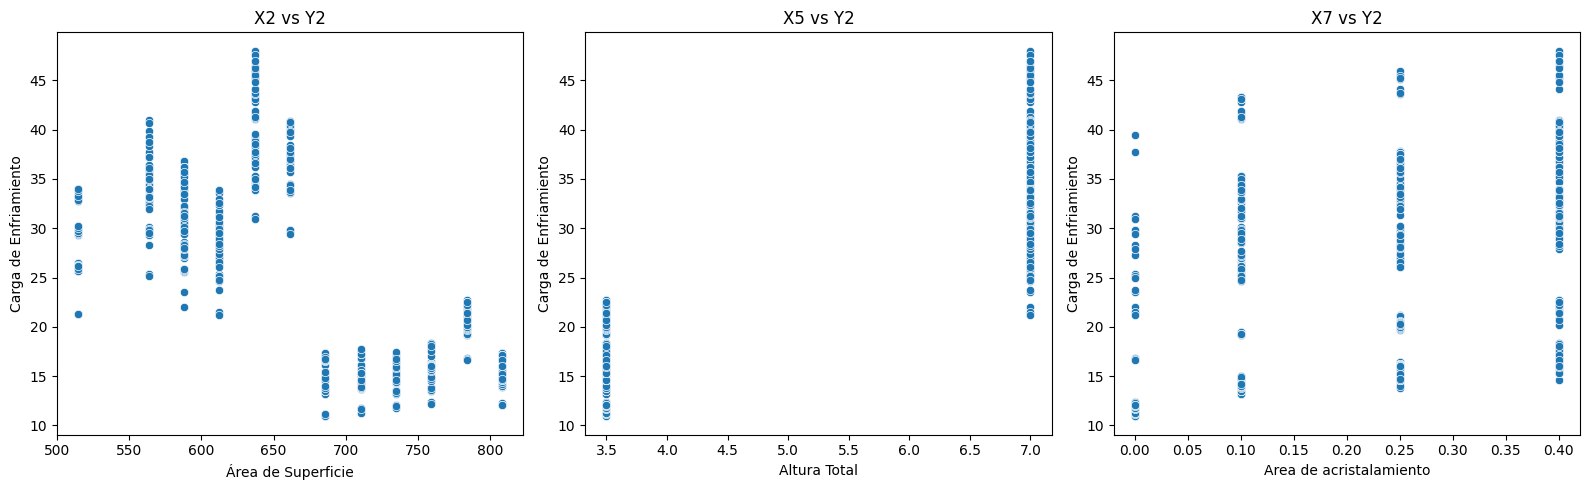

In [32]:
print_title('Relación entre features y variable objetivo')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# X2 vs Y2
sns.scatterplot(x=df['X2'], y=df['Y2'], ax=axes[0])
axes[0].set_title('X2 vs Y2')
axes[0].set_xlabel('Área de Superficie')
axes[0].set_ylabel('Carga de Enfriamiento')

# X5 vs Y2
sns.scatterplot(x=df['X5'], y=df['Y2'], ax=axes[1])
axes[1].set_title('X5 vs Y2')
axes[1].set_xlabel('Altura Total')
axes[1].set_ylabel('Carga de Enfriamiento')

# X7 vs Y2
sns.scatterplot(x=df['X7'], y=df['Y2'], ax=axes[2])
axes[2].set_title('X7 vs Y2')
axes[2].set_xlabel('Area de acristalamiento')
axes[2].set_ylabel('Carga de Enfriamiento')

plt.tight_layout()
plt.show()

> -  En el gráfico corespondiente a X2 y Y2 se observan distinto grupos de observaciones y una dispersión moderada de los datos.
>
> - En X5 y Y2 puede verse una diferencia marcada entre los valores de Y2 según X5, los valores más altos de X5 suelen estar asociados a valores más altos de Y2.
>
> - En X7 y Y2 se aprecia una tendencia creciente donde mayores valores de X7 tienden a relacionarse con mayores valores de Y2, aunque hay cierta dispersión en los datos.

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.  
   - Dividan en train/test (70-30 o 80-20).  

## Resolución:

### 3.1 Objetivo

El objetivo de esta etapa es preparar los datos para que el modelo pueda trabajar con ellos correctamente. Se tratarán inconsistencias, transformación de variables con la finalidad de que el dataset esté listo para el entrenamiento.

### 3.2 Manejo de valores faltantes

In [33]:
# En la documentación se explica que no hay valores faltantes
# pero igualmente inspeccionamos el dataset
print('Detección de valores nulos')
df.isnull().sum()

Detección de valores nulos


,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
Y1,0
Y2,0


Detección de valores nulos


,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
Y1,0
Y2,0


> Se confirma que el dataset no posee valores faltantes

### 3.3 Detección de outliers

 🔷 Detección visual de outliers



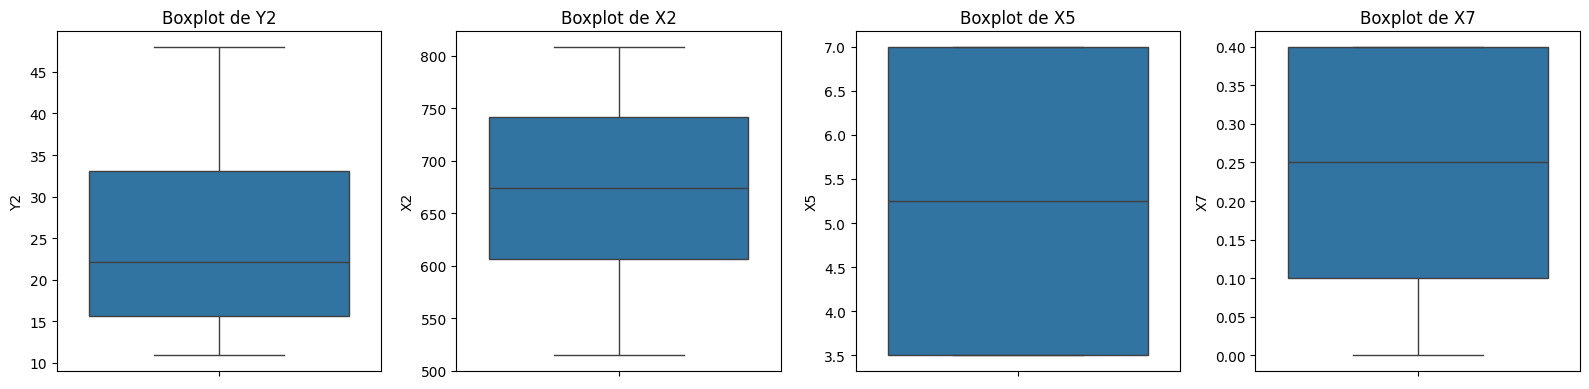

 🔷 Detección visual de outliers



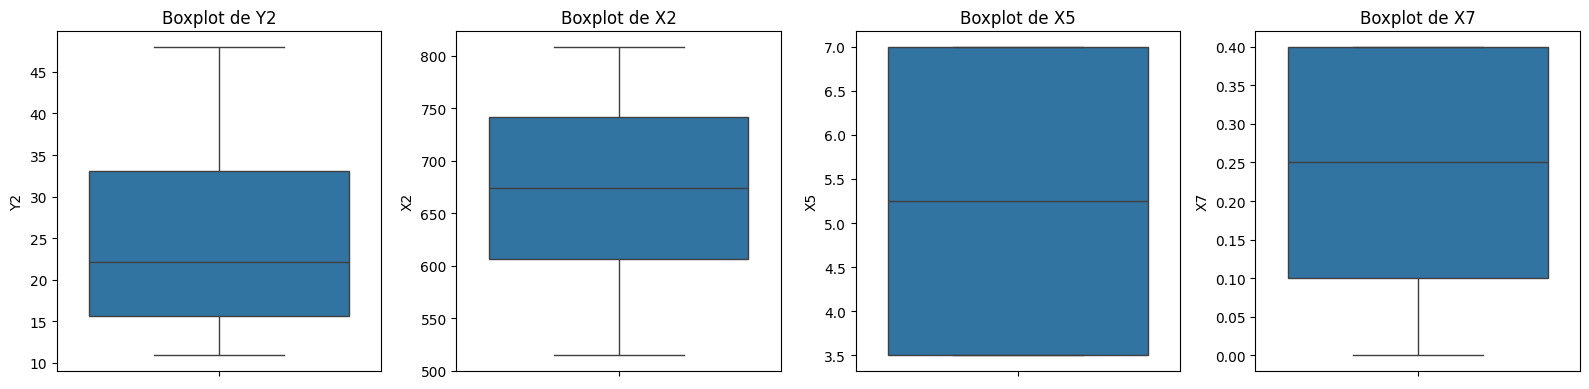

In [34]:
print_title('Detección visual de outliers')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Y2
sns.boxplot(y=df['Y2'], ax=axes[0])
axes[0].set_title('Boxplot de Y2')

# X2
sns.boxplot(y=df['X2'], ax=axes[1])
axes[1].set_title('Boxplot de X2')

# X5
sns.boxplot(y=df['X5'], ax=axes[2])
axes[2].set_title('Boxplot de X5')

# X7
sns.boxplot(y=df['X7'], ax=axes[3])
axes[3].set_title('Boxplot de X7')

plt.tight_layout()
plt.show()

> A partir de los boxplots realizados sobre las variables seleccionadas no se observan outliers extremos que puedan considerarse ruido. Las variables presentan diferentes niveles de dispersión y variabilidad. X5 y X7 muestran un comportamiento debido a su limitado rango.
>
> No se consideró necesario aplicar tratamiento específico de outliers debido a que el dataset no presenta valores atípicos que puedan afectar significativamente al modelado.

### 3.4 Selección y descarte de variables


> Se decidió conservar las variables predictoras originales del dataset debido a que no presentan valores faltantes y muestran información potencialmente importante para la predicción de la variable objetivo.

In [35]:
print_title('Selección de variables')

X = df.drop(columns=['Y1', 'Y2'])

y = df['Y2']

print(f'X: {X.shape}')
print(f'y: {y.shape}')

 🔷 Selección de variables

X: (768, 8)
y: (768,)
 🔷 Selección de variables

X: (768, 8)
y: (768,)


### 3.5 Variables categóricas

> El dataset no presenta variables categóricas en formato textual, por lo que no fue necesario aplicar técnicas de codificación adicionales.

### 3.6 Escalado de variables

Las variables del dataset presentan diferentes escalas y rangos de valores, lo que puede influir en el comportamiento del modelo. Por este motivo, se aplicará un proceso de escalado sobre las features numéricas para que las variables tengan rangos similares antes de entrenar al modelo.

In [36]:
print_title('Estandarización de features')

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

 🔷 Estandarización de features



,X1,X2,X3,X4,X5,X6,X7,X8
0,2.041777,-1.785875,-0.561951,-1.470077,1.0,-1.341641,-1.760447,-1.814575
1,2.041777,-1.785875,-0.561951,-1.470077,1.0,-0.447214,-1.760447,-1.814575
2,2.041777,-1.785875,-0.561951,-1.470077,1.0,0.447214,-1.760447,-1.814575
3,2.041777,-1.785875,-0.561951,-1.470077,1.0,1.341641,-1.760447,-1.814575
4,1.284979,-1.229239,0.000000,-1.198678,1.0,-1.341641,-1.760447,-1.814575


 🔷 Estandarización de features



,X1,X2,X3,X4,X5,X6,X7,X8
0,2.041777,-1.785875,-0.561951,-1.470077,1.0,-1.341641,-1.760447,-1.814575
1,2.041777,-1.785875,-0.561951,-1.470077,1.0,-0.447214,-1.760447,-1.814575
2,2.041777,-1.785875,-0.561951,-1.470077,1.0,0.447214,-1.760447,-1.814575
3,2.041777,-1.785875,-0.561951,-1.470077,1.0,1.341641,-1.760447,-1.814575
4,1.284979,-1.229239,0.000000,-1.198678,1.0,-1.341641,-1.760447,-1.814575


### 3.7 División train/test

Se eligió 80-20 por balance entre entrenamiento y evaluación.

In [37]:
print_title('Train/Test split')

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

 🔷 Train/Test split

 🔷 Train/Test split



### 3.8 Resultados del preprocesamiento

> Finalizada la etapa de preprocesamiento, el dataset quedó preparado para el entrenamiento del modelo de regresión lineal.

In [38]:
print_title('Resultados')

print(f'Cantidad de features finales: {X.shape[1]}')
print(f'Cantidad total de muestras: {X.shape[0]}')
print(f'Cantidad de muestras de entrenamiento: {X_train.shape[0]}')
print(f'Cantidad de muestras de prueba: {X_test.shape[0]}')

 🔷 Resultados

Cantidad de features finales: 8
Cantidad total de muestras: 768
Cantidad de muestras de entrenamiento: 614
Cantidad de muestras de prueba: 154
 🔷 Resultados

Cantidad de features finales: 8
Cantidad total de muestras: 768
Cantidad de muestras de entrenamiento: 614
Cantidad de muestras de prueba: 154


## 4. **Regresión Lineal**  
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).  
   - Obtengan:  
     - Coeficientes (pesos) del modelo.  
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, MSE (error cuadrático medio), MAE.  


## Resolución:

### 4.1 Objetivo

El objetivo del modelo es poder predecir la variable Y2 (Carga de enfriamiento) a partir de las features del dataset mediante un modelo de regresión lineal. Se busca analizar qué tan bien las features pueden estimar el consumo de enfriamiento y evaluar cuáles tienen mayor influencia sobre la predicción.

### 4.2 Entrenamiento del modelo

Se utilizó el modelo de regresión lineal de la librería scikit-learn.

In [39]:
print_title('Creación y Entrenamiento del modelo')

model = LinearRegression()

model.fit(X_train, y_train)

 🔷 Creación y Entrenamiento del modelo



LinearRegression()

 🔷 Creación y Entrenamiento del modelo



LinearRegression()

### 4.3 Obtención de predicciones

In [40]:
print_title('Predicciones')

# predicciones sobre entrenamiento
y_train_pred = model.predict(X_train)

# predicciones sobre prueba
y_test_pred = model.predict(X_test)

 🔷 Predicciones

 🔷 Predicciones



### 4.4 Coeficientes del modelo

Luego del entrenamiento, se analizan los coeficientes obtenidos por el modelo de regresión lineal, estos coeficientes permitirán observar cómo afecta cada feature al target (Y2).

Valores positivos indican relación directa y valores negativos representan relación inversa.

In [41]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': model.coef_
})

coef_df

,Feature,Coeficiente
0,X1,-7.514245
1,X2,-4.155150
2,X3,0.148460
3,X4,-4.123546
4,X5,7.080781
5,X6,0.061727
6,X7,1.968728
7,X8,0.052296


,Feature,Coeficiente
0,X1,-7.514245
1,X2,-4.155150
2,X3,0.148460
3,X4,-4.123546
4,X5,7.080781
5,X6,0.061727
6,X7,1.968728
7,X8,0.052296


In [42]:
print_title('Intercepto del modelo')

print(model.intercept_)

 🔷 Intercepto del modelo

24.514822809641334
 🔷 Intercepto del modelo

24.514822809641334


> Los coeficientes obtenidos muestran que las variables X1 y X5 son las que presentan mayor influencia sobre la variable objetivo Y2 debido a que poseen los valores absolutos más altos. Además los coeficientes positivos de X5 y X7 indican una relación directa con la variable objetivo, mientras que coeficientes negativos como X1, X2 y X4 indican relación inversa.

### 4.5 Evaluación del modelo

 🔷 Evaluación

--- Entrenamiento ---
R2: 0.8859
MSE: 10.2282
MAE: 2.2531

--- Test ---
R2: 0.8932
MSE: 9.8934
MAE: 2.1953


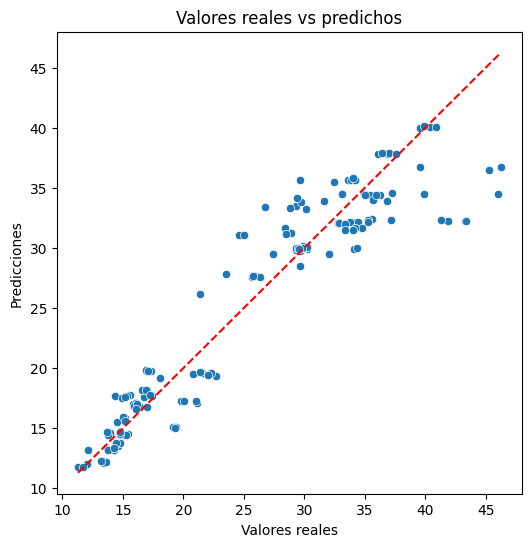

In [44]:
print_title('Evaluación')

# métricas entrenamiento
train_r2 = r2_score(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)

# métricas test
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print('--- Entrenamiento ---')
print(f'R2: {train_r2:.4f}')
print(f'MSE: {train_mse:.4f}')
print(f'MAE: {train_mae:.4f}')

print('\n--- Test ---')
print(f'R2: {test_r2:.4f}')
print(f'MSE: {test_mse:.4f}')
print(f'MAE: {test_mae:.4f}')

plt.figure(figsize=(6,6))

sns.scatterplot(x=y_test, y=y_test_pred)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores reales vs predichos")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.show()

> Los resultados muestran valores similares en ambos conjuntos, lo que indica que el modelo tiene un comportamiento estable y no parece presentar overfitting. Además los valores de R2 ambos cercanos a 0.89 muestran que el modelo consigue explicar la variabilidad de Y2 mientras que los valores de MSE y MAE indican que los errores de predicción son relativamente bajos.

### 4.6 Interpretación de resultados

A partir de los resultados obtenidos, se observa que el modelo de regresión lineal logró un buen desempeño para la predicción de la variable Y2 (carga de enfriamiento). Las métricas obtenidas fueron similares, lo que indica que el modelo generaliza bien sobre datos no vistos.

Observar los coeficientes perimitió identificar que variables como X1 y X5 tienen mayor influencia sobre la variable objetivo. También se observaron erlaciones directas e inversas entre distintas features y Y2.

En general, el modelo consigue explicar gran parte de la variabilidad de la variable objetivo y obtuvo errores relativamente bajos por lo que puede considerarse adecuado para este problema de regresión lineal.


## 5. **Importancia de Variables**  
   - Analicen los **coeficientes** del modelo:  
     - Valores absolutos altos → mayor impacto en el target.  
     - Signo: Relación positiva/negativa con el target.  
   - Comparen la magnitud de los coeficientes **escalados** (si usaron features en distintas unidades).  
   - **5.1. Opcional**:
     Otra forma es "desordenar" un feature y ver cómo empeora el modelo. Si al desordenarlo el error aumenta mucho, ese feature era importante. Usen métodos como:  
     - **Permutation Importance** (de sklearn) para validar importancia. Más info en https://scikit-learn.org/stable/modules/permutation_importance.html



## Resolución:

### 5.1 Análisis de Coeficientes

El análisis de los coeficientes del modelo de regresión lineal nos permite entender la influencia y la dirección de la relación de cada feature con la variable objetivo. Un valor absoluto alto indica un mayor impacto, mientras que el signo (positivo o negativo) indica la dirección de la relación.

In [45]:
print_title('Coeficientes del modelo de regresión lineal')

# Display the previously calculated coefficients again for easy reference
display(coef_df)

print(f'Intercepto del modelo: {model.intercept_:.4f}')

 🔷 Coeficientes del modelo de regresión lineal



,Feature,Coeficiente
0,X1,-7.514245
1,X2,-4.155150
2,X3,0.148460
3,X4,-4.123546
4,X5,7.080781
5,X6,0.061727
6,X7,1.968728
7,X8,0.052296


Intercepto del modelo: 24.5148


A partir de los coeficientes mostrados, se puede observar que:

*   **X1 (Compactación Relativa)** y **X5 (Altura Total)** tienen los coeficientes con mayor magnitud absoluta, indicando que son las variables que más influyen en la predicción de la carga de enfriamiento (Y2).
*   **X1** tiene un coeficiente negativo, indicando una relación inversa: a mayor compactación relativa, menor es la carga de enfriamiento.
*   **X5** tiene un coeficiente positivo, indicando una relación directa: a mayor altura total, mayor es la carga de enfriamiento.
*   **X2 (Área de Superficie)** y **X4 (Área de Techo)** también tienen coeficientes negativos de magnitud considerable, indicando una relación inversa con Y2.
*   **X3 (Área de Muro)**, **X6 (Orientación)**, **X7 (Área de Acristalamiento)** y **X8 (Distribución del Área de Acristalamiento)** tienen coeficientes cercanos a cero o de menor magnitud, lo que indica una menor influencia en la predicción de Y2 en comparación con las otras variables.

### 5.2 Permutation Importance

Para validar la importancia de las variables, utilizaremos la 'Permutation Importance'.

Este método mide la disminución en el rendimiento del modelo cuando una característica se permuta aleatoriamente. Una mayor disminución en el rendimiento indica que la característica es más importante.

 🔷 Cálculo de Permutation Importance



,Feature,Importance_Mean,Importance_Std
0,X1,1.251347,0.052533
4,X5,1.095127,0.090405
3,X4,0.379205,0.029007
1,X2,0.374772,0.031791
6,X7,0.073774,0.009739
2,X3,0.000551,0.001011
5,X6,0.000538,0.000469
7,X8,0.000218,0.000252


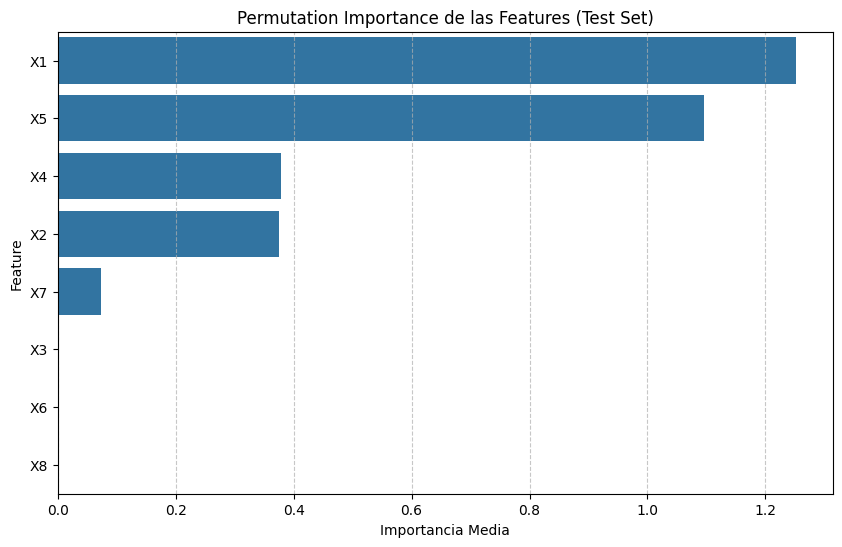

In [48]:
print_title('Cálculo de Permutation Importance')

# calculamos Permutation Importance en el conjunto de test
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# creamos un DataFrame para visualizar los resultados
perm_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

display(perm_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance_Mean', y='Feature', data=perm_importance_df)
plt.title('Permutation Importance de las Features (Test Set)')
plt.xlabel('Importancia Media')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

> Los resultados de Permutation Importance generalmente confirman los hallazgos del análisis de coeficientes.
>
> Las características con los coeficientes de mayor magnitud absoluta (X1 y X5) suelen aparecer como las más importantes en el Permutation Importance, indicando mayor confianza en la identificación de las variables clave para la predicción de la carga de enfriamiento.


## 6. **Reflexión**  
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?  
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?  



## Resolución:

### 6.1 Importancia de las Variables

El análisis de coeficientes y Permutation Importance identifica **X1 (Compactación Relativa)** y **X5 (Altura Total)** como las variables más influyentes en Y2. X1 tiene una relación inversa, y X5 una relación directa. X2 (Área de Superficie) y X4 (Área de Techo) también muestran influencia significativa con relación inversa. Estos hallazgos coinciden con el análisis exploratorio inicial, validando la importancia de X1 y X5.

### 6.2 Rendimiento del Modelo

El modelo de regresión lineal exhibe un buen rendimiento general. El **R²** (0.886 en entrenamiento, 0.893 en prueba) indica que el modelo explica ~89% de la variabilidad de Y2. **MSE** (10.23 y 9.89) y **MAE** (2.25 y 2.20) son bajos y consistentes entre los conjuntos de entrenamiento y prueba, sugiriendo que el modelo generaliza bien sin sobreajuste. En resumen, el modelo es adecuado para predecir la carga de enfriamiento (Y2).


## **Bonus**:  
- Prueben eliminar variables "poco importantes" y reentrenar el modelo. ¿Mejora el rendimiento?  


---

### **Tips**:  
- Si el R² es muy bajo, revisen si hay relaciones no lineales (y consideren transformar features).  
- Documenten cada paso: ¡la trazabilidad es clave en ciencia de datos!  
- Al final de su trabajo debe crear un apartado de REFERENCIAS para citar todo recurso utilizado. Si usó IA, debe


# 7. Referencias

### Uso de IA

- [Chat usado para scaffolding del Notebook](https://chatgpt.com/share/6a1297c9-3f70-83e9-8e7f-c6153eec4b22)

### Documentación

- [Repositorio oficial del Dataset](https://archive.ics.uci.edu/dataset/242/energy+efficiency)

### Referencias para código
- [Ejemplo de Regresión Lineal](https://scikit-learn.org/1.5/auto_examples/linear_model/plot_ols.html)
